# 🧬 RecurrentBitNet V3: Selective BitLinear on Qwen3.5

**Hypothesis**: Gated DeltaNet layers are more robust to ternary (1.58-bit) quantization than standard attention layers, because their recurrent state matrix accumulates in full precision and the delta rule provides error-correcting memory updates.

**This notebook**:
1. Loads Qwen3.5-0.8B and measures baseline quality
2. Surgically converts 18 DeltaNet layers to BitLinear (ternary weights)
3. Measures quality degradation from quantization
4. Runs knowledge distillation to recover quality
5. Compares all three measurements

---

## 🔧 Setup & Configuration

In [1]:
# Install dependencies
%pip install -q git+https://github.com/huggingface/transformers.git datasets accelerate matplotlib huggingface_hub

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import sys

REPO_URL = "https://github.com/angrysky56/recurrent_bitnet.git"  # UPDATE THIS
REPO_DIR = "/content/recurrent_bitnet"

# --- HuggingFace token (faster authenticated downloads) ---
HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN')
    print('🔑 HF_TOKEN loaded from Colab secrets')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN')
    if HF_TOKEN:
        print('🔑 HF_TOKEN loaded from environment')
    else:
        print('ℹ️  No HF_TOKEN found (optional — public models download without it)')

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

# --- Repo setup ---
if os.path.exists('/content'):  # Colab
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    sys.path.insert(0, REPO_DIR)
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = '/content/drive/MyDrive/recurrent_bitnet/checkpoints'
else:  # Local
    REPO_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
    sys.path.insert(0, REPO_DIR)
    CHECKPOINT_DIR = os.path.join(REPO_DIR, 'checkpoints')

print(f'Repo: {REPO_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')

🔑 HF_TOKEN loaded from Colab secrets
Cloning into '/content/recurrent_bitnet'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 32 (delta 10), reused 31 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 48.05 KiB | 820.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.
Mounted at /content/drive
Repo: /content/recurrent_bitnet
Checkpoints: /content/drive/MyDrive/recurrent_bitnet/checkpoints


In [3]:
MODEL_SIZE = "0.8B"  #@param ["0.8B", "2B", "4B"]
SURGERY_AGGRESSION = "standard"  #@param ["conservative", "standard", "aggressive"]
NUM_DISTILL_STEPS = 5000  #@param {type: "integer"}

_MODEL_MAP = {
    "0.8B": "Qwen/Qwen3.5-0.8B-Base",
    "2B": "Qwen/Qwen3.5-2B-Base",
    "4B": "Qwen/Qwen3.5-4B-Base",
}
_TEACHER_MAP = {
    "0.8B": "Qwen/Qwen3.5-0.8B-Base",
    "2B": "Qwen/Qwen3.5-4B-Base",
    "4B": "Qwen/Qwen3.5-9B-Base",
}

STUDENT_MODEL = _MODEL_MAP[MODEL_SIZE]
TEACHER_MODEL = _TEACHER_MAP[MODEL_SIZE]

import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name} ({gpu_vram:.1f} GB)')
else:
    gpu_name = 'CPU'
    gpu_vram = 0
    print('⚠️  No GPU detected. Training will be very slow.')

if gpu_vram < 20 and MODEL_SIZE != '0.8B':
    print(f'⚠️  {MODEL_SIZE} may not fit on {gpu_vram:.0f}GB. Consider 0.8B.')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nStudent: {STUDENT_MODEL}')
print(f'Teacher: {TEACHER_MODEL}')
print(f'Surgery: {SURGERY_AGGRESSION}')
print(f'Steps:   {NUM_DISTILL_STEPS}')

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (102.0 GB)

Student: Qwen/Qwen3.5-0.8B-Base
Teacher: Qwen/Qwen3.5-0.8B-Base
Surgery: standard
Steps:   5000


In [4]:
from src.bitlinear import BitLinear, count_ternary_params
from src.surgery import convert_model, SurgeryConfig, surgical_report, identify_layer_types
from src.distill import (
    DistillationTrainer, DistillationConfig,
    create_dataloader, compute_model_perplexity,
)

print('✅ Modules imported successfully')

✅ Modules imported successfully


---
## 📊 Phase A: Baseline Measurement

Load the original Qwen3.5 model and measure its perplexity as our quality baseline.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    STUDENT_MODEL, trust_remote_code=True, token=HF_TOKEN
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Loading {STUDENT_MODEL}...')
model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL,
    torch_dtype=torch.float32,
    trust_remote_code=True,
    token=HF_TOKEN,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Loaded: {total_params:,} parameters')
print(f'Model size (FP32): {total_params * 4 / 1e9:.2f} GB')
print(f'Model size (FP16): {total_params * 2 / 1e9:.2f} GB')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading Qwen/Qwen3.5-0.8B-Base...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded: 752,393,024 parameters
Model size (FP32): 3.01 GB
Model size (FP16): 1.50 GB


In [6]:
# Inspect the layer structure
layer_info = identify_layer_types(model)
print(f"{'Layer':>6} | {'Type':>10} | {'Class':>30} | Linears")
print('-' * 80)
for idx, info in layer_info.items():
    marker = '🔵' if info['type'] == 'deltanet' else '🔴'
    linears = ', '.join(info['linears'][:4])
    if len(info['linears']) > 4:
        linears += f" (+{len(info['linears'])-4} more)"
    print(f"{marker} {idx:>4} | {info['type']:>10} | {info['class']:>30} | {linears}")

 Layer |       Type |                          Class | Linears
--------------------------------------------------------------------------------
🔵    0 |   deltanet |            Qwen3_5DecoderLayer | linear_attn.out_proj, linear_attn.in_proj_qkv, linear_attn.in_proj_z, linear_attn.in_proj_b (+4 more)
🔵    1 |   deltanet |            Qwen3_5DecoderLayer | linear_attn.out_proj, linear_attn.in_proj_qkv, linear_attn.in_proj_z, linear_attn.in_proj_b (+4 more)
🔵    2 |   deltanet |            Qwen3_5DecoderLayer | linear_attn.out_proj, linear_attn.in_proj_qkv, linear_attn.in_proj_z, linear_attn.in_proj_b (+4 more)
🔴    3 |  attention |            Qwen3_5DecoderLayer | self_attn.q_proj, self_attn.k_proj, self_attn.v_proj, self_attn.o_proj (+3 more)
🔵    4 |   deltanet |            Qwen3_5DecoderLayer | linear_attn.out_proj, linear_attn.in_proj_qkv, linear_attn.in_proj_z, linear_attn.in_proj_b (+4 more)
🔵    5 |   deltanet |            Qwen3_5DecoderLayer | linear_attn.out_proj, linear_attn.in_

In [7]:
eval_config = DistillationConfig(batch_size=2, seq_length=1024)
eval_loader = create_dataloader(eval_config, tokenizer)

print('Measuring baseline perplexity...')
baseline = compute_model_perplexity(model, eval_loader, num_samples=50, device=DEVICE)
print(f"\n📊 BASELINE: Loss = {baseline['loss']:.4f}, Perplexity = {baseline['perplexity']:.2f}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'HuggingFaceFW/fineweb-edu' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'HuggingFaceFW/fineweb-edu' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Measuring baseline perplexity...


Measuring Perplexity:   0%|          | 0/50 [00:00<?, ?it/s]


📊 BASELINE: Loss = 5.5157, Perplexity = 248.56


---
## 🔬 Phase B: Surgical BitLinear Conversion

Convert the 18 DeltaNet layers from `nn.Linear` to `BitLinear` (ternary weights).
The 6 Full Attention layers stay at full precision.

In [8]:
surgery_config = SurgeryConfig(aggression=SURGERY_AGGRESSION)
report = convert_model(model, surgery_config)
print(surgical_report(model, report))


  SURGICAL REPORT — RecurrentBitNet V3
  Aggression level:   standard
  Modules converted:  54
  Modules skipped:    132
--------------------------------------------------------------
  BitLinear params:    198,180,864  (26.3%)
  FP Linear params:    553,713,664
  Other params:            599,872
  Total params:        752,494,400
--------------------------------------------------------------
  Est. inference size: 1158 MB



In [9]:
print('Measuring post-surgery perplexity (expect degradation)...')
post_surgery = compute_model_perplexity(model, eval_loader, num_samples=50, device=DEVICE)

print(f"\n📊 POST-SURGERY: Loss = {post_surgery['loss']:.4f}, Perplexity = {post_surgery['perplexity']:.2f}")
print(f"   Quality drop: {((post_surgery['perplexity'] / baseline['perplexity']) - 1) * 100:.1f}% perplexity increase")

Measuring post-surgery perplexity (expect degradation)...


Measuring Perplexity:   0%|          | 0/50 [00:00<?, ?it/s]


📊 POST-SURGERY: Loss = 17.2293, Perplexity = 30380925.33
   Quality drop: 12222494.1% perplexity increase


---
## 🎓 Phase C: Knowledge Distillation

Train the BitLinear student to recover quality by distilling from the original
(full-precision) teacher model. The combined loss uses:
- Cross-entropy on hard labels (next-token prediction)
- KL divergence on temperature-scaled soft labels from the teacher
- Temperature annealing from T=4.0 → T=1.0 (cosine schedule)

In [10]:
print(f'Loading teacher: {TEACHER_MODEL}...')
teacher = AutoModelForCausalLM.from_pretrained(
    TEACHER_MODEL,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
    token=HF_TOKEN,
).to(DEVICE)

teacher_params = sum(p.numel() for p in teacher.parameters())
print(f'Teacher: {teacher_params:,} params ({teacher_params * 2 / 1e9:.2f} GB in BF16)')

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {allocated:.1f} / {total_mem:.1f} GB used')

Loading teacher: Qwen/Qwen3.5-0.8B-Base...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Teacher: 752,393,024 params (1.50 GB in BF16)
VRAM: 3.0 / 102.0 GB used


In [11]:
distill_config = DistillationConfig(
    num_steps=NUM_DISTILL_STEPS,
    checkpoint_dir=CHECKPOINT_DIR,
)
distill_config.auto_configure(gpu_vram)

train_loader = create_dataloader(distill_config, tokenizer)
trainer = DistillationTrainer(model, teacher, distill_config)

print(f"\nEffective batch: {distill_config.effective_batch_tokens:,} tokens/step")
print(f"Total tokens: ~{distill_config.effective_batch_tokens * distill_config.num_steps / 1e6:.0f}M")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'HuggingFaceFW/fineweb-edu' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'HuggingFaceFW/fineweb-edu' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


Effective batch: 32,768 tokens/step
Total tokens: ~164M


In [12]:
# Optional: resume from checkpoint
# trainer.load_checkpoint('/content/drive/MyDrive/recurrent_bitnet/checkpoints/checkpoint-2500.pt')

In [13]:
# Run distillation!
trainer.train(train_loader)

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step     10 | Loss 6848.0000 | CE 12.7812 | KD 6848.0000 | T 4.00 | LR 1.00e-05 | 4970 tok/s
Step     20 | Loss 2524.0000 | CE 7.6719 | KD 2524.0000 | T 4.00 | LR 2.00e-05 | 5013 tok/s
Step     30 | Loss 1714.0000 | CE 7.2578 | KD 1714.0000 | T 4.00 | LR 3.00e-05 | 5028 tok/s
Step     40 | Loss 1652.0000 | CE 7.2734 | KD 1652.0000 | T 4.00 | LR 4.00e-05 | 5018 tok/s
Step     50 | Loss 1584.0000 | CE 6.7969 | KD 1584.0000 | T 4.00 | LR 5.00e-05 | 5027 tok/s
Step     60 | Loss 1120.0000 | CE 5.5234 | KD 1120.0000 | T 4.00 | LR 6.00e-05 | 5020 tok/s
Step     70 | Loss 1137.0000 | CE 5.3828 | KD 1136.0000 | T 4.00 | LR 7.00e-05 | 5029 tok/s
Step     80 | Loss 1122.0000 | CE 4.8125 | KD 1120.0000 | T 4.00 | LR 8.00e-05 | 5029 tok/s
Step     90 | Loss 971.0000 | CE 4.2656 | KD 969.0000 | T 4.00 | LR 9.00e-05 | 5014 tok/s
Step    100 | Loss 1054.0000 | CE 4.1836 | KD 1054.0000 | T 4.00 | LR 1.00e-04 | 5026 tok/s
Step    110 | Loss 821.0000 | CE 3.5781 | KD 821.0000 | T 4.00 | LR 1.10e-04 | 50

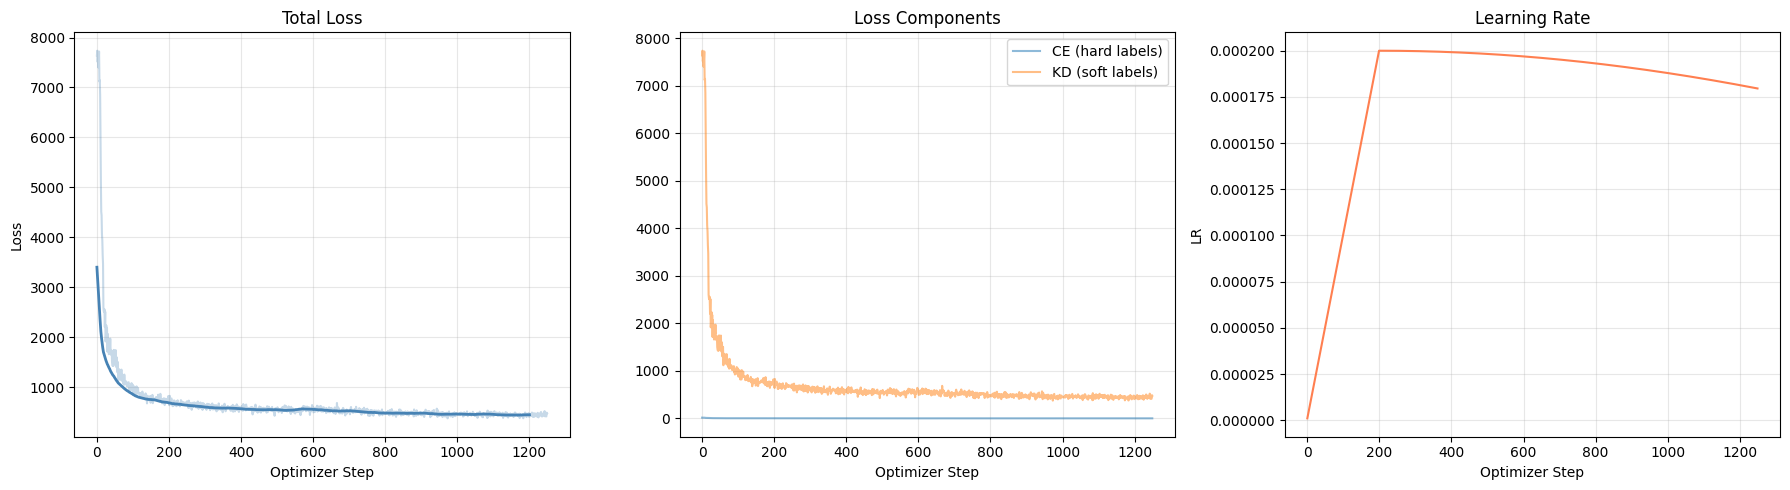

In [14]:
trainer.plot_loss_curves()

In [15]:
print('Measuring post-distillation perplexity...')
post_distill = compute_model_perplexity(model, eval_loader, num_samples=50, device=DEVICE)
print(f"\n📊 POST-DISTILLATION: Loss = {post_distill['loss']:.4f}, Perplexity = {post_distill['perplexity']:.2f}")

Measuring post-distillation perplexity...


Measuring Perplexity:   0%|          | 0/50 [00:00<?, ?it/s]


📊 POST-DISTILLATION: Loss = 3.3505, Perplexity = 28.52


---
## 📈 Results: The Three-Number Story

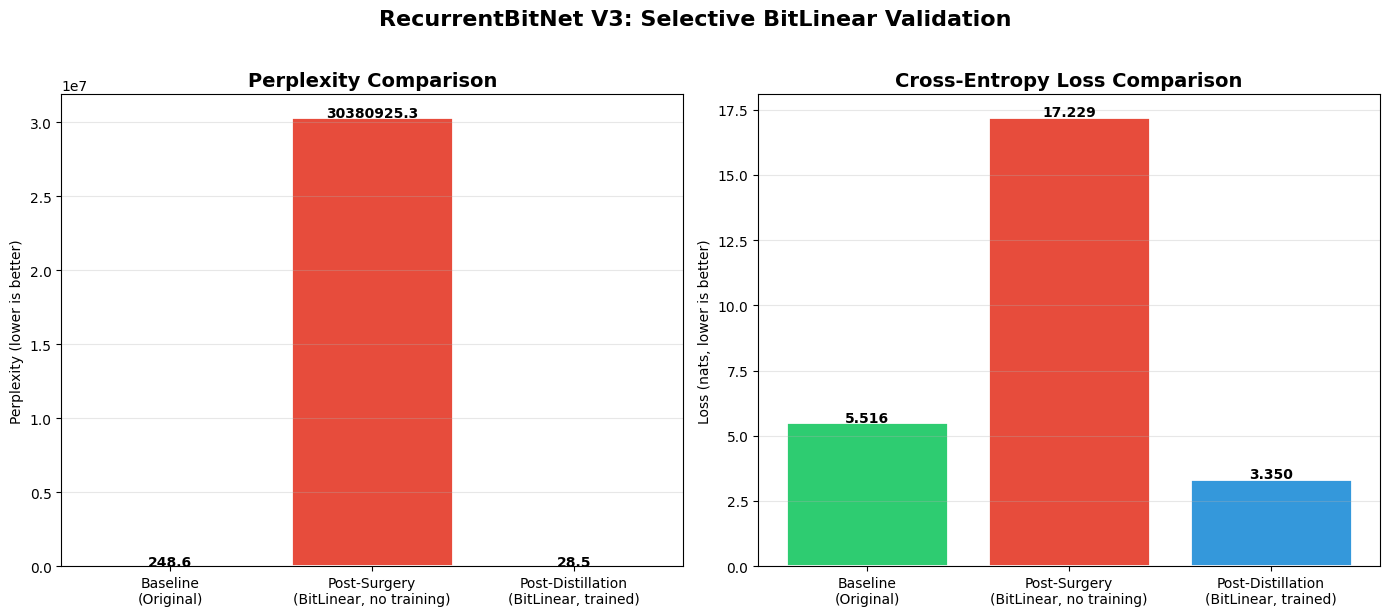


  RESULTS SUMMARY
  Baseline perplexity:       248.56
  Post-surgery perplexity:   30380925.33  (+12222494.1%)
  Post-distillation:         28.52  (+-88.5%)
  Quality recovery:          100.0%
  BitLinear params:          26.3% of model
  Est. inference size:       1158 MB


In [16]:
import matplotlib.pyplot as plt

phases = ['Baseline\n(Original)', 'Post-Surgery\n(BitLinear, no training)', 'Post-Distillation\n(BitLinear, trained)']
ppls = [baseline['perplexity'], post_surgery['perplexity'], post_distill['perplexity']]
losses = [baseline['loss'], post_surgery['loss'], post_distill['loss']]
colors = ['#2ecc71', '#e74c3c', '#3498db']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(phases, ppls, color=colors, edgecolor='white', linewidth=2)
ax1.set_title('Perplexity Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Perplexity (lower is better)')
for bar, ppl in zip(bars1, ppls):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{ppl:.1f}', ha='center', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(phases, losses, color=colors, edgecolor='white', linewidth=2)
ax2.set_title('Cross-Entropy Loss Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Loss (nats, lower is better)')
for bar, loss in zip(bars2, losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{loss:.3f}', ha='center', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('RecurrentBitNet V3: Selective BitLinear Validation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

stats = count_ternary_params(model)
recovery = 1.0 - (post_distill['perplexity'] - baseline['perplexity']) / (post_surgery['perplexity'] - baseline['perplexity'])
print(f"\n{'='*60}")
print(f'  RESULTS SUMMARY')
print(f"{'='*60}")
print(f"  Baseline perplexity:       {baseline['perplexity']:.2f}")
print(f"  Post-surgery perplexity:   {post_surgery['perplexity']:.2f}  (+{((post_surgery['perplexity']/baseline['perplexity'])-1)*100:.1f}%)")
print(f"  Post-distillation:         {post_distill['perplexity']:.2f}  (+{((post_distill['perplexity']/baseline['perplexity'])-1)*100:.1f}%)")
print(f"  Quality recovery:          {recovery*100:.1f}%")
print(f"  BitLinear params:          {stats['bitlinear_pct']:.1f}% of model")
print(f"  Est. inference size:       {stats['est_size_mb']:.0f} MB")
print(f"{'='*60}")

---
## 💾 Save & Export

In [17]:
import json

save_path = os.path.join(CHECKPOINT_DIR, 'recurrent_bitnet_v3_final')
os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

metadata = {
    'model': STUDENT_MODEL,
    'teacher': TEACHER_MODEL,
    'surgery_aggression': SURGERY_AGGRESSION,
    'distill_steps': trainer.global_step,
    'baseline_ppl': baseline['perplexity'],
    'post_surgery_ppl': post_surgery['perplexity'],
    'post_distill_ppl': post_distill['perplexity'],
    'param_stats': count_ternary_params(model),
}
with open(os.path.join(save_path, 'experiment_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f'✅ Model saved to {save_path}')
print(f'   Metadata: experiment_metadata.json')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to /content/drive/MyDrive/recurrent_bitnet/checkpoints/recurrent_bitnet_v3_final
   Metadata: experiment_metadata.json


---
## 🔮 What's Next: V2 Architecture

If this V3 validation shows that DeltaNet layers tolerate ternary quantization
(quality recovery > 80%), the next step is **V2**: weight-sharing recurrence
on top of the BitLinear'd Qwen3.5 layers.

V2 adds:
- **Depth recurrence**: same blocks execute R times with iteration embeddings
- **Adaptive halting**: stop recurring when representation stabilizes
- **Progressive recurrence curriculum**: train R=1→2→3→4
- **Auxiliary per-recurrence loss**: each intermediate step predicts next token

This would create a model with 298M unique params that behaves like 430M+,
running inference in ~75 MB.